# Regressão de NPS 📊

## Sobre a base de dados 🎲
O dataset utilizado representa um cenário de um **e-commerce**, que enfrenta desafios relacionados à **experiência do cliente**.  

Cada registro corresponde a um **pedido realizado**, contendo informações sobre o cliente, detalhes da compra, logística de entrega e interações com o atendimento.

A base inclui variáveis como tempo de entrega, atrasos, valor do pedido, número de contatos com suporte, reclamações e indicadores internos de satisfação.

---

## Uso da base 🛠️
O conjunto de dados pode ser utilizado para:

- Análises de **experiência do cliente (CX)**
- Identificação de **fatores que impactam o NPS**
- Construção de **modelos preditivos de satisfação**
- Geração de **insights para áreas como logística, atendimento e produto**

---

## Objetivo do projeto 🎯
Este projeto tem como objetivo **analisar os fatores que influenciam a satisfação do cliente** e **desenvolver um modelo preditivo para estimar o NPS** antes da coleta oficial.

A proposta é permitir que a empresa atue de forma **proativa**, antecipando problemas e melhorando a experiência do cliente ao longo da jornada.

---

## Contexto de negócio 💼

![Jornada do Cliente e NPS](../images/nps-image-example.png)

O NPS (Net Promoter Score) é um dos principais indicadores de satisfação e lealdade do cliente.  

Atualmente, ele é coletado apenas após a finalização da compra, o que limita a capacidade da empresa de agir preventivamente.

Com o uso de dados operacionais, buscamos responder:
- O que leva um cliente a ser promotor ou detrator?
- Quais etapas da jornada impactam mais a experiência?
- Como antecipar a satisfação do cliente?

---

## Impacto esperado 🚀
Com essa análise, espera-se:

- Melhorar a **experiência do cliente**
- Reduzir **detratores**
- Aumentar **recompra e fidelização**
- Apoiar decisões estratégicas com base em dados

---

In [45]:
#Libs - Exploração e Manipulação de dados

import pandas as pd
import numpy as np

#Libs Gráficas
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Paletas
NPS_COLORS   = {'Detrator': '#e74c6f', 'Neutro': '#f0a500', 'Promotor': '#2ec4b6'}
REGION_PAL   = ['#7c4dff','#00bcd4','#ff6f61','#ffd54f','#69f0ae']
DIVERGE_CMAP = 'RdYlGn'
HEAT_CMAP    = LinearSegmentedColormap.from_list('nps', ['#e74c6f','#f0a500','#2ec4b6'])



## 1. ENTENDIMENTO DOS DADOS - EDA Detalhado

Conhecer os dados é uma etapa essencial na construção de um modelo de aprendizado de máquina. 

Nessa fase, exploramos o conjunto de dados, criamos gráficos, testamos hipóteses e validamos as informações com a área de negócio para garantir qualidade e entendimento dos dados.

In [46]:
# Carregar dados
df = pd.read_csv('../data/desafio_nps_fase_1.csv')
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [47]:
# Análise de valores ausentes e tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64


### Variável alvo: `nps_score`

Para este projeto, a variável alvo definida será o `nps_score`, pois ela representa diretamente o nível de satisfação do cliente ao final da jornada de compra e entrega, sendo o principal indicador de experiência utilizado no case.

Essa escolha faz sentido porque o objetivo do modelo é prever a probabilidade de um cliente se tornar promotor, neutro ou detrator, permitindo que a empresa atue preventivamente antes da insatisfação se consolidar.

O `nps_score` possibilita transformar percepções subjetivas de experiência em uma métrica quantitativa, facilitando análises preditivas e a identificação dos principais fatores que impactam a satisfação.

### Riscos

A nota de NPS pode sofrer influência de situações pontuais e externas ao processo principal, como problemas momentâneos de atendimento, atrasos específicos, expectativas individuais do cliente ou até fatores emocionais no momento da resposta.

Isso pode gerar certa variabilidade no comportamento da variável alvo, exigindo cuidado no tratamento estatístico e na interpretação dos resultados.

### Momento da coleta

O NPS é coletado ao final da jornada do cliente, após a conclusão da entrega e da experiência completa de compra.

Isso significa que a variável alvo reflete uma percepção consolidada da experiência vivida, sendo extremamente valiosa para identificar padrões que antecedem a satisfação ou a insatisfação do cliente.

### Faixas de avaliação de satisfação 📊

#### NPS (Net Promoter Score)

- **Promotores**: notas 9 ou 10  
- **Neutros**: notas 7 ou 8  
- **Detratores**: notas de 0 a 6  

---

#### CSAT (Customer Satisfaction Score)
O CSAT mede a **satisfação direta do cliente com uma experiência específica**, como uma compra ou atendimento.

![Exemplo de escala CSAT](../images/CSAT-EXAMPLE.jpg)

- **0 a 2**: Muito insatisfeito  
- **2 a 4**: Insatisfeito  
- **4 a 6**: Indiferente  
- **6 a 8**: Satisfeito  
- **8 a 10**: Muito satisfeito  

In [48]:
# =========================================================
# Classificação de NPS e CSAT + Salvando no DataFrame
# Mantendo os nomes originais das variáveis
# =========================================================

# ---------------------------------------------------------
# NPS
# ---------------------------------------------------------

# Classificação da nota NPS em:
# Detrator (0 a 6)
# Neutro (7 a 8)
# Promotor (9 a 10)

nps = pd.cut(
    df['nps_score'],
    [-float('inf'), 6.9, 8.9, float('inf')],
    labels=['Detrator', 'Neutro', 'Promotor']
)

# Percentual de cada categoria
pct_nps = nps.value_counts(normalize=True)

# Cálculo do NPS:
# % Promotores - % Detratores

nps_score = round(
    (
        pct_nps.get('Promotor', 0)
        - pct_nps.get('Detrator', 0)
    ) * 100
)

print(f"NPS Score: {nps_score}")

# ---------------------------------------------------------
# CSAT
# ---------------------------------------------------------

# Classificação da nota CSAT em níveis de satisfação

csat = pd.cut(
    df['csat_internal_score'],
    [-float('inf'), 2.9, 4.9, 6.9, 8.9, float('inf')],
    labels=[
        'Muito insatisfeito',
        'Insatisfeito',
        'Indiferente',
        'Satisfeito',
        'Muito satisfeito'
    ]
)

# Percentual de cada categoria
pct_csat = csat.value_counts(normalize=True)

# Cálculo do CSAT:
# % Satisfeito + % Muito satisfeito

csat_score = round(
    (
        pct_csat.get('Satisfeito', 0)
        + pct_csat.get('Muito satisfeito', 0)
    ) * 100
)

print(f"CSAT Score: {csat_score}")

# ---------------------------------------------------------
# Salvar colunas no DataFrame principal
# ---------------------------------------------------------

df['nps_category'] = nps
df['csat_category'] = csat

# ---------------------------------------------------------
# Conferência rápida
# ---------------------------------------------------------

print("\nDistribuição NPS:")
print(df['nps_category'].value_counts())

print("\nDistribuição CSAT:")
print(df['csat_category'].value_counts())

NPS Score: -80
CSAT Score: 5

Distribuição NPS:
nps_category
Detrator    2109
Neutro       281
Promotor     110
Name: count, dtype: int64

Distribuição CSAT:
csat_category
Muito insatisfeito    1325
Insatisfeito           612
Indiferente            426
Satisfeito             123
Muito satisfeito        14
Name: count, dtype: int64


In [49]:
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_category,csat_category
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,55.53,3,0,4,6.9,0,3,6.5,Detrator,Indiferente
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,28.23,3,0,10,2.4,0,3,0.0,Detrator,Muito insatisfeito
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,40.99,1,4,5,4.8,0,7,1.5,Detrator,Muito insatisfeito
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,35.24,3,1,11,5.9,0,4,0.3,Detrator,Muito insatisfeito
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,39.32,1,1,0,6.1,0,3,7.9,Detrator,Satisfeito


Distribuição NPS:
nps_score
Detrator    84.36
Neutro      11.24
Promotor     4.40
Name: proportion, dtype: float64

Distribuição CSAT:
csat_internal_score
Muito insatisfeito    53.00
Insatisfeito          24.48
Indiferente           17.04
Satisfeito             4.92
Muito satisfeito       0.56
Name: proportion, dtype: float64


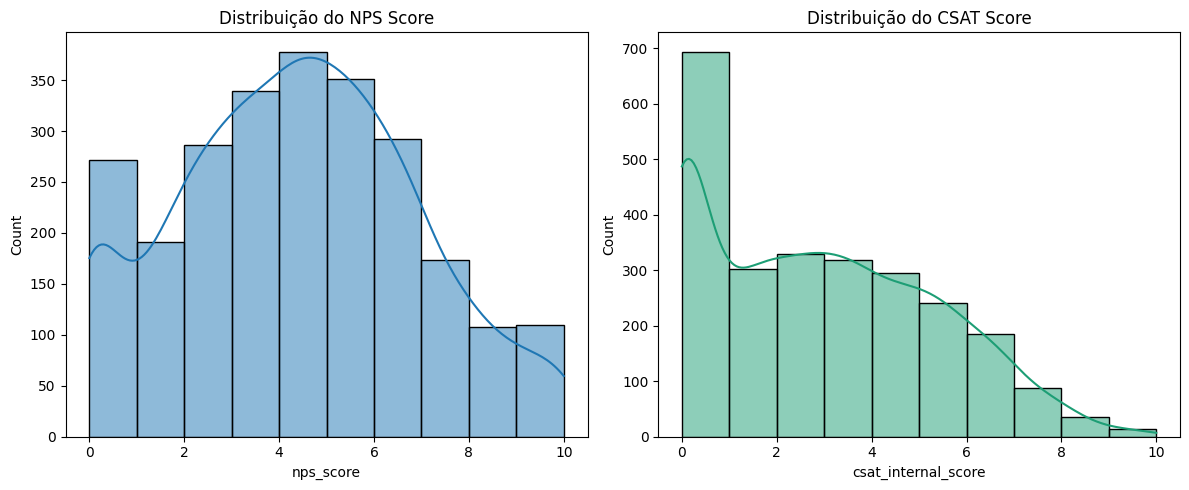

In [50]:
#distribuição percentual de cada categoria para nps e csat

distribuição_nps = nps.value_counts(normalize=True) * 100
distribuição_csat = csat.value_counts(normalize=True) * 100
print("Distribuição NPS:")
print(distribuição_nps)
print("\nDistribuição CSAT:")
print(distribuição_csat)

#grafico histrograma para nps_score e csat_score
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['nps_score'], bins=10, kde=True)
plt.title('Distribuição do NPS Score')
plt.subplot(1, 2, 2)
sns.histplot(df['csat_internal_score'], bins=10, kde=True, color="#1D9E75")
plt.title('Distribuição do CSAT Score')
plt.tight_layout()
plt.show()


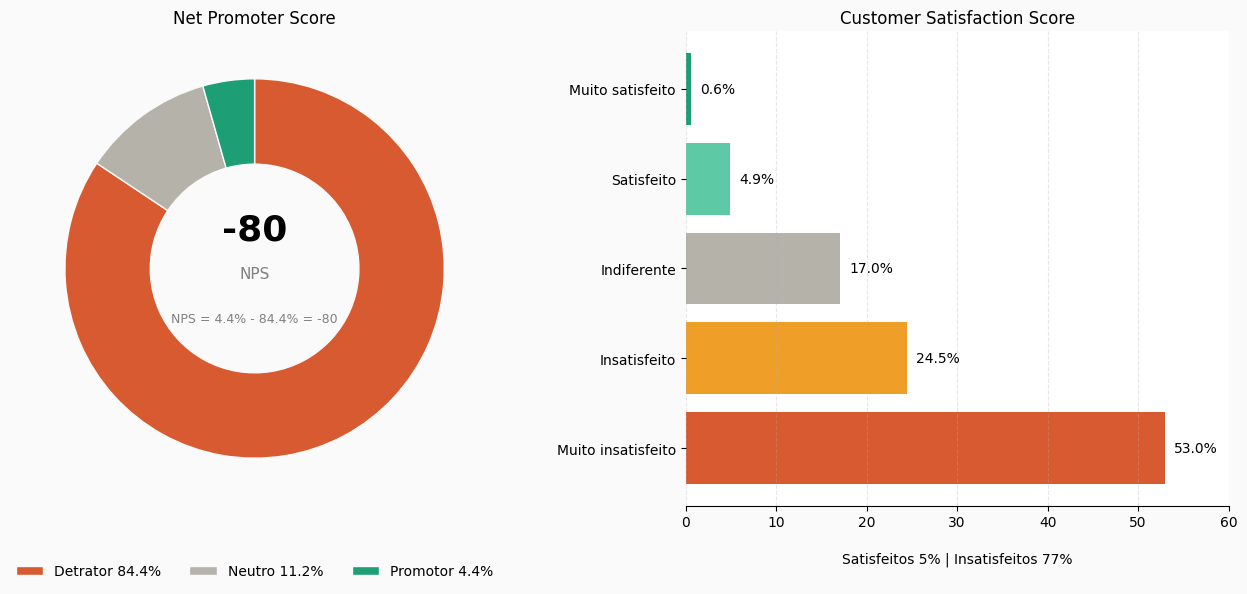

In [51]:
# =========================================================
# Dashboard visual de satisfação do cliente
# Este bloco gera dois gráficos principais:
# 1. NPS (Net Promoter Score) em formato de rosca,
#    mostrando a distribuição entre Detratores,
#    Neutros e Promotores.
#
# 2. CSAT (Customer Satisfaction Score) em barras
#    horizontais, exibindo os níveis de satisfação
#    dos clientes e o percentual consolidado de
#    satisfeitos e insatisfeitos.
#
# O objetivo é facilitar a análise visual da
# experiência do cliente e apoiar a tomada de
# decisão baseada em dados.
# =========================================================

fig, (ax_nps, ax_csat) = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('#FAFAFA')

# ── NPS (rosca) ─────────────────────
COLORS_NPS = ['#D85A30', '#B4B2A9', '#1D9E75']
labels_nps = ['Detrator', 'Neutro', 'Promotor']
sizes_nps = [pct_nps.get(l, 0) for l in labels_nps]

# cálculo visual do NPS
promotores_pct = pct_nps.get('Promotor', 0) * 100
detratores_pct = pct_nps.get('Detrator', 0) * 100
regra_nps = f"NPS = {promotores_pct:.1f}% - {detratores_pct:.1f}% = {nps_score:+}"

ax_nps.pie(
    sizes_nps,
    colors=COLORS_NPS,
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='#FAFAFA'),
    counterclock=False
)

ax_nps.text(
    0,
    0.15,
    f'{nps_score:+}',
    ha='center',
    fontsize=26,
    fontweight='bold'
)

ax_nps.text(
    0,
    -0.05,
    'NPS',
    ha='center',
    fontsize=11,
    color='gray'
)

ax_nps.text(
    0,
    -0.28,
    regra_nps,
    ha='center',
    fontsize=9,
    color='gray'
)

ax_nps.set_title('Net Promoter Score')

ax_nps.legend(
    [f'{l} {pct_nps.get(l,0)*100:.1f}%' for l in labels_nps],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False
)

# ── CSAT (barras) ───────────────────
COLORS_CSAT = ['#D85A30', '#EF9F27', '#B4B2A9', '#5DCAA5', '#1D9E75']
labels_csat = [
    'Muito insatisfeito',
    'Insatisfeito',
    'Indiferente',
    'Satisfeito',
    'Muito satisfeito'
]

sizes_csat = [pct_csat.get(l, 0) * 100 for l in labels_csat]

bars = ax_csat.barh(
    labels_csat,
    sizes_csat,
    color=COLORS_CSAT
)

for bar in bars:
    w = bar.get_width()
    ax_csat.text(
        w + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{w:.1f}%',
        va='center'
    )

ax_csat.set_xlim(0, 60)
ax_csat.set_title('Customer Satisfaction Score')

ax_csat.spines[['top', 'right', 'left']].set_visible(False)
ax_csat.grid(axis='x', linestyle='--', alpha=0.3)

# resumo (satisfeitos vs insatisfeitos)
insat = (
    pct_csat.get('Muito insatisfeito', 0) +
    pct_csat.get('Insatisfeito', 0)
) * 100

ax_csat.text(
    0.5,
    -0.12,
    f'Satisfeitos {csat_score}% | Insatisfeitos {insat:.0f}%',
    transform=ax_csat.transAxes,
    ha='center',
)

plt.tight_layout()
plt.show()

Os indicadores demonstram um cenário bastante crítico na experiência do cliente. O NPS de -80 evidencia uma predominância expressiva de clientes detratores, com uma quantidade muito reduzida de promotores, indicando um alto nível de insatisfação e baixa propensão à recomendação da empresa.

O CSAT reforça essa análise, mostrando que mais de 75% dos clientes se encontram insatisfeitos, enquanto o percentual de clientes satisfeitos é bastante reduzido. Esse comportamento aponta para falhas relevantes na jornada do cliente, exigindo uma investigação aprofundada das principais causas e a definição de ações corretivas com maior prioridade.

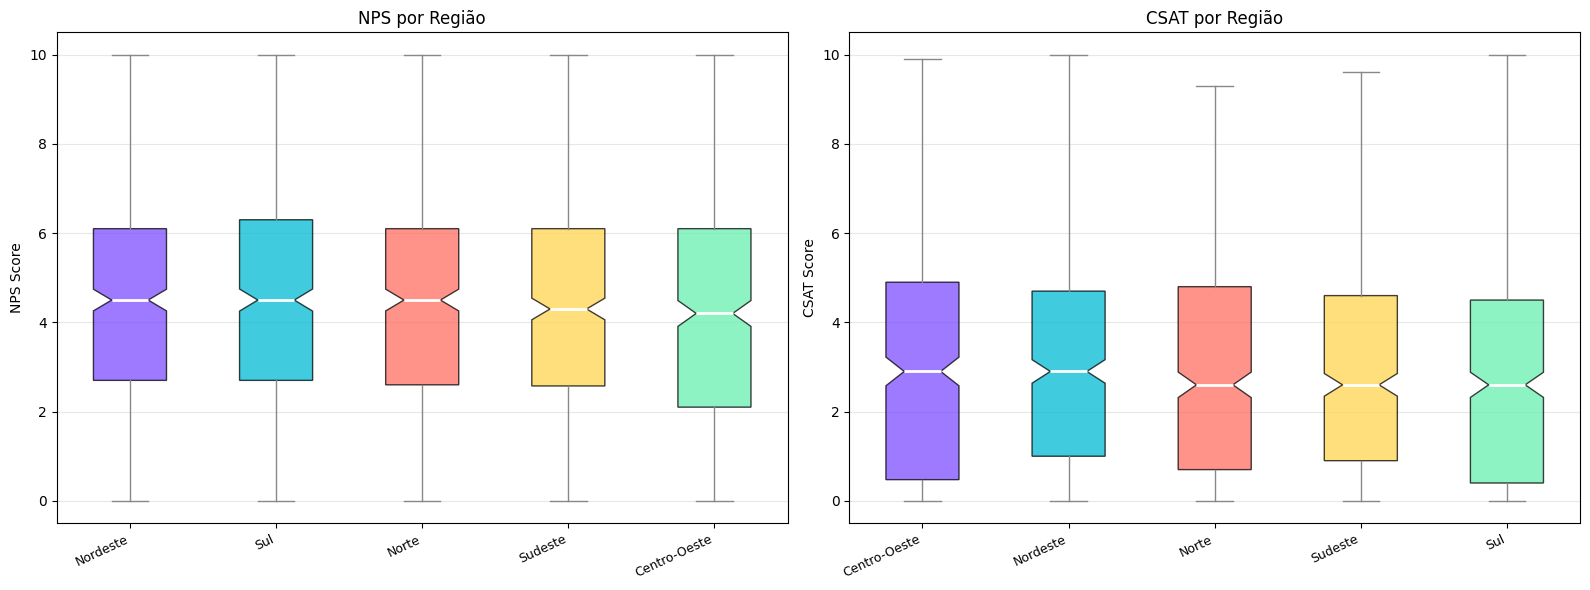

In [52]:
# =========================================================
# Análise comparativa de NPS e CSAT por região
#
# Este bloco utiliza boxplots para visualizar a distribuição
# das notas de NPS e CSAT em cada região atendida.
#
# O objetivo é identificar diferenças regionais no nível de
# satisfação dos clientes, observando mediana, dispersão,
# presença de outliers e possíveis variações relevantes
# entre as localidades.
#
# Essa análise permite detectar regiões com maior risco de
# insatisfação e apoiar decisões estratégicas mais direcionadas.
# =========================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- NPS por Região ---
regs_nps = df.groupby('customer_region')['nps_score'].median().sort_values(ascending=False).index
data_nps = [df[df['customer_region'] == r]['nps_score'].values for r in regs_nps]

bp1 = ax1.boxplot(
    data_nps,
    patch_artist=True,
    notch=True,
    medianprops={'color': '#fff', 'linewidth': 2},
    whiskerprops={'color': '#888'},
    capprops={'color': '#888'},
    flierprops={'marker': 'o', 'markerfacecolor': '#ff6b6b', 'markersize': 3, 'alpha': 0.4}
)
for patch, color in zip(bp1['boxes'], REGION_PAL):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax1.set_xticklabels(regs_nps, rotation=25, ha='right', fontsize=9)
ax1.set_title('NPS por Região')
ax1.set_ylabel('NPS Score')
ax1.grid(axis='y', alpha=0.3)

# --- CSAT por Região ---
regs_csat = df.groupby('customer_region')['csat_internal_score'].median().sort_values(ascending=False).index
data_csat = [df[df['customer_region'] == r]['csat_internal_score'].values for r in regs_csat]

bp2 = ax2.boxplot(
    data_csat,
    patch_artist=True,
    notch=True,
    medianprops={'color': '#fff', 'linewidth': 2},
    whiskerprops={'color': '#888'},
    capprops={'color': '#888'},
    flierprops={'marker': 'o', 'markerfacecolor': '#ff6b6b', 'markersize': 3, 'alpha': 0.4}
)
for patch, color in zip(bp2['boxes'], REGION_PAL):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_xticklabels(regs_csat, rotation=25, ha='right', fontsize=9)
ax2.set_title('CSAT por Região')
ax2.set_ylabel('CSAT Score')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

A análise regional demonstra que não há diferenças expressivas entre as regiões em relação aos indicadores de NPS e CSAT. Os resultados permanecem relativamente homogêneos, com medianas próximas e elevada dispersão interna em todas as localidades avaliadas.

Esse comportamento indica que a insatisfação dos clientes não está concentrada em uma região específica, mas sim distribuída de forma ampla, sugerindo um problema estrutural na experiência do cliente ao longo de toda a operação, e não uma falha isolada regionalmente.

Diante desse cenário, não se justifica a aplicação de testes A/B segmentados por região neste momento, uma vez que não há divergências significativas que sustentem a necessidade de tratamentos distintos entre as localidades. O direcionamento mais adequado é a atuação sobre causas estruturais comuns a toda a operação.

C:\Users\Edy O Cruel\AppData\Local\Temp\ipykernel_1716\1404903256.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  idades_nps = df.groupby('faixa_etaria')['nps_score'].median().sort_values(ascending=False).index
C:\Users\Edy O Cruel\AppData\Local\Temp\ipykernel_1716\1404903256.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  idades_csat = df.groupby('faixa_etaria')['csat_internal_score'].median().sort_values(ascending=False).index


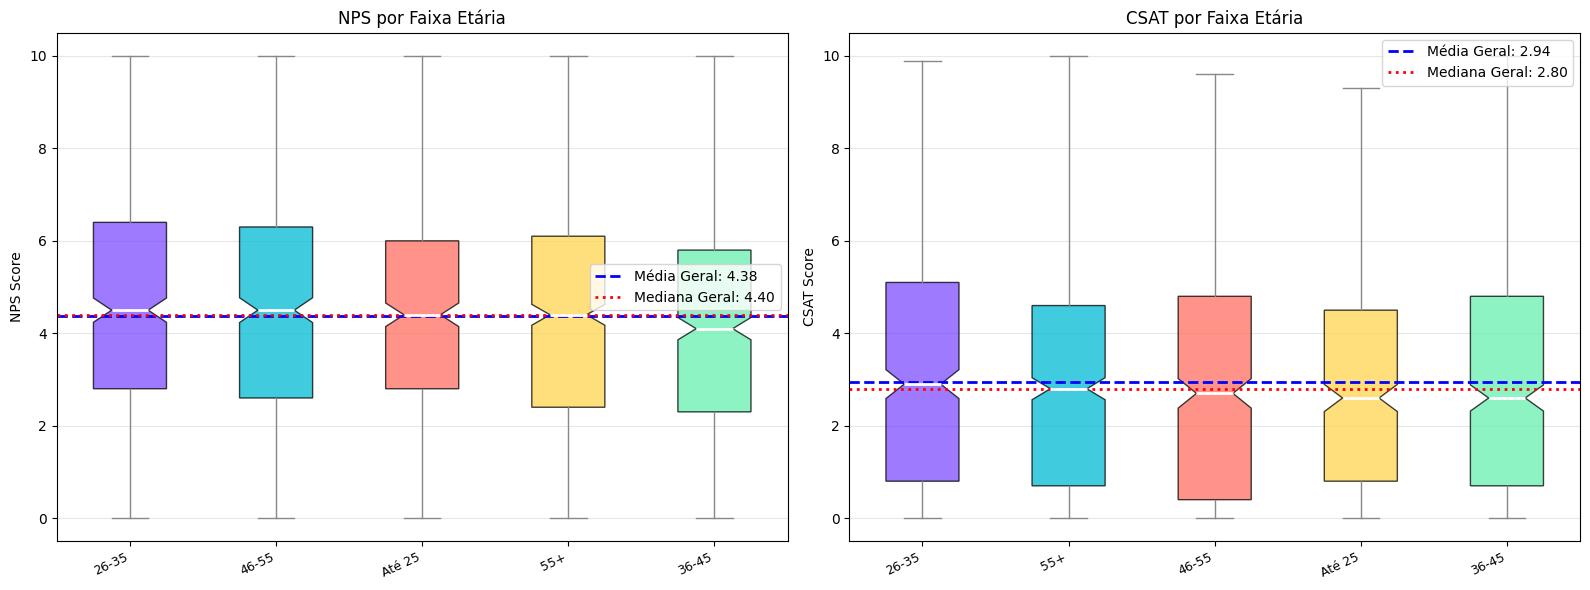

In [53]:
# =========================================================
# Análise comparativa de NPS e CSAT por faixa etária
#
# Este bloco utiliza boxplots para visualizar a distribuição
# das notas de NPS e CSAT por grupos de idade dos clientes.
#
# O objetivo é identificar diferenças no nível de satisfação
# entre diferentes faixas etárias, observando mediana,
# dispersão, presença de outliers e possíveis variações
# relevantes entre os grupos.
#
# Essa análise permite detectar perfis etários com maior
# risco de insatisfação e apoiar decisões estratégicas
# mais direcionadas.
# =========================================================

# Criação das faixas etárias
df['faixa_etaria'] = pd.cut(
    df['customer_age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=[
        'Até 25',
        '26-35',
        '36-45',
        '46-55',
        '55+'
    ]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# =========================================================
# NPS por Faixa Etária
# =========================================================

idades_nps = df.groupby('faixa_etaria')['nps_score'].median().sort_values(ascending=False).index
data_nps = [df[df['faixa_etaria'] == i]['nps_score'].values for i in idades_nps]

bp1 = ax1.boxplot(
    data_nps,
    patch_artist=True,
    notch=True,
    medianprops={'color': '#fff', 'linewidth': 2},
    whiskerprops={'color': '#888'},
    capprops={'color': '#888'},
    flierprops={
        'marker': 'o',
        'markerfacecolor': '#ff6b6b',
        'markersize': 3,
        'alpha': 0.4
    }
)

for patch, color in zip(bp1['boxes'], REGION_PAL):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Linha de média geral
media_nps = df['nps_score'].mean()
ax1.axhline(
    media_nps,
    linestyle='--',
    linewidth=2,
    color='blue',
    label=f'Média Geral: {media_nps:.2f}'
)

# Linha de mediana geral
mediana_nps = df['nps_score'].median()
ax1.axhline(
    mediana_nps,
    linestyle=':',
    linewidth=2,
    color='red',
    label=f'Mediana Geral: {mediana_nps:.2f}'
)

ax1.set_xticklabels(idades_nps, rotation=25, ha='right', fontsize=9)
ax1.set_title('NPS por Faixa Etária')
ax1.set_ylabel('NPS Score')
ax1.grid(axis='y', alpha=0.3)
ax1.legend()

# =========================================================
# CSAT por Faixa Etária
# =========================================================

idades_csat = df.groupby('faixa_etaria')['csat_internal_score'].median().sort_values(ascending=False).index
data_csat = [df[df['faixa_etaria'] == i]['csat_internal_score'].values for i in idades_csat]

bp2 = ax2.boxplot(
    data_csat,
    patch_artist=True,
    notch=True,
    medianprops={'color': '#fff', 'linewidth': 2},
    whiskerprops={'color': '#888'},
    capprops={'color': '#888'},
    flierprops={
        'marker': 'o',
        'markerfacecolor': '#ff6b6b',
        'markersize': 3,
        'alpha': 0.4
    }
)

for patch, color in zip(bp2['boxes'], REGION_PAL):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Linha de média geral
media_csat = df['csat_internal_score'].mean()
ax2.axhline(
    media_csat,
    linestyle='--',
    linewidth=2,
    color='blue',
    label=f'Média Geral: {media_csat:.2f}'
)

# Linha de mediana geral
mediana_csat = df['csat_internal_score'].median()
ax2.axhline(
    mediana_csat,
    linestyle=':',
    linewidth=2,
    color='red',
    label=f'Mediana Geral: {mediana_csat:.2f}'
)

ax2.set_xticklabels(idades_csat, rotation=25, ha='right', fontsize=9)
ax2.set_title('CSAT por Faixa Etária')
ax2.set_ylabel('CSAT Score')
ax2.grid(axis='y', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

A análise por faixa etária demonstra que não há diferenças expressivas entre os grupos em relação aos indicadores de NPS e CSAT. As medianas permanecem muito próximas da média geral, com elevada dispersão em todas as faixas analisadas, indicando um comportamento relativamente homogêneo entre os perfis etários.

Esse cenário sugere que a insatisfação dos clientes não está concentrada em uma faixa etária específica, mas distribuída de forma ampla entre os diferentes grupos de idade. Dessa forma, não se justifica neste momento a segmentação de estratégias ou testes A/B por perfil etário, sendo mais adequado concentrar esforços em melhorias estruturais da experiência do cliente como um todo.

P(possui atendimento): 77.84%
P(possui atendimento e possui reclamação): 77.84%
P(possui reclamação | possui atendimento): 100.00%


,customer_id,customer_service_contacts,complaints_count,possui_atendimento,possui_reclamacao,eh_detrator
0,1,0,3,0,1,0
1,2,0,3,0,1,1
2,3,4,7,1,1,1
3,4,1,4,1,1,1
4,5,1,3,1,1,0
...,...,...,...,...,...,...
95,96,3,5,1,1,1
96,97,1,4,1,1,0
97,98,2,5,1,1,1
98,99,1,3,1,1,0


C:\Users\Edy O Cruel\AppData\Local\Temp\ipykernel_1716\3981266061.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


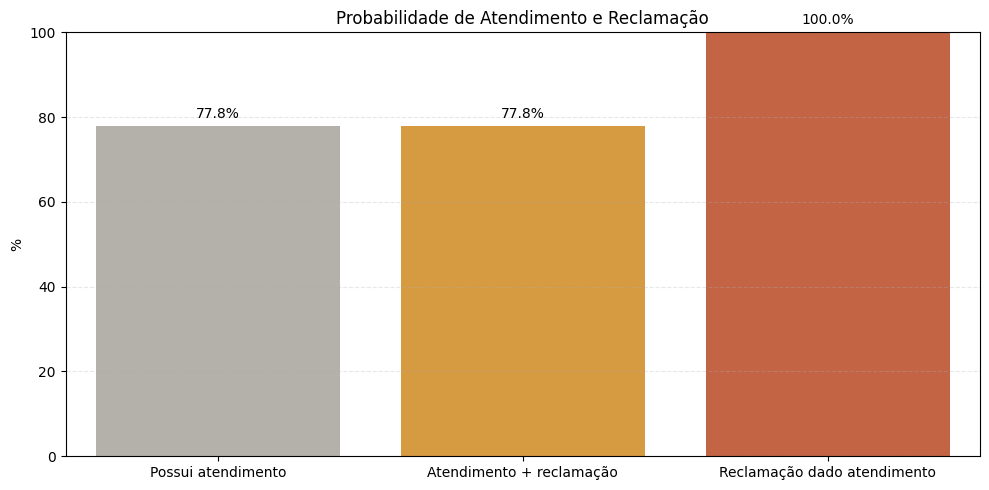

In [54]:
# =========================================================
# Análise de probabilidade: atendimento x reclamação
#
# Este bloco cria variáveis auxiliares para identificar
# clientes que acionaram atendimento, registraram reclamação
# e foram classificados como detratores.
#
# Em seguida, calcula:
# - Probabilidade de o cliente acionar atendimento
# - Probabilidade conjunta de atendimento e reclamação
# - Probabilidade de reclamação dado que houve atendimento
#
# O objetivo é avaliar a relação entre contato com suporte,
# abertura de reclamação e possíveis sinais de insatisfação.
# =========================================================

# ---------------------------------------------------------
# Criação das variáveis auxiliares
# ---------------------------------------------------------

df['possui_reclamacao'] = np.where(
    df['complaints_count'] > 0,
    1,
    0
)

df['eh_detrator'] = np.where(
    df['nps_score'] <= 6,
    1,
    0
)

df['possui_atendimento'] = np.where(
    df['customer_service_contacts'] > 0,
    1,
    0
)

# ---------------------------------------------------------
# Cálculo das probabilidades
# ---------------------------------------------------------

total = len(df)

P_A = df['possui_atendimento'].mean()

P_A_e_B = (
    (df['possui_atendimento'] == 1) &
    (df['possui_reclamacao'] == 1)
).mean()

P_B_dado_A = P_A_e_B / P_A if P_A > 0 else 0

# ---------------------------------------------------------
# Exibição dos resultados
# ---------------------------------------------------------

print(f'P(possui atendimento): {P_A:.2%}')
print(f'P(possui atendimento e possui reclamação): {P_A_e_B:.2%}')
print(f'P(possui reclamação | possui atendimento): {P_B_dado_A:.2%}')

# ---------------------------------------------------------
# Amostra para conferência
# ---------------------------------------------------------

display(
    df[
        [
            'customer_id',
            'customer_service_contacts',
            'complaints_count',
            'possui_atendimento',
            'possui_reclamacao',
            'eh_detrator'
        ]
    ].head(100)
)

# ---------------------------------------------------------
# Gráfico comparativo das probabilidades
# ---------------------------------------------------------

labels_prob = [
    'Possui atendimento',
    'Atendimento + reclamação',
    'Reclamação dado atendimento'
]

valores_prob = [
    P_A * 100,
    P_A_e_B * 100,
    P_B_dado_A * 100
]

plt.figure(figsize=(10, 5))

bars = sns.barplot(
    x=labels_prob,
    y=valores_prob,
    palette=['#B4B2A9', '#EF9F27', '#D85A30']
)

plt.title('Probabilidade de Atendimento e Reclamação')
plt.ylabel('%')
plt.xlabel('')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.3)

for i, v in enumerate(valores_prob):
    plt.text(
        i,
        v + 2,
        f'{v:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

A probabilidade condicional é um dos fundamentos teóricos mais utilizados em modelos probabilísticos de classificação, análise de comportamento de usuários, detecção de fraudes, e em diversos outros domínios da ciência de dados. Sua importância decorre do fato de que grande parte dos fenômenos estudados nessa área envolve eventos dependentes, em que o conhecimento prévio de uma variável altera a probabilidade de outra. 

A análise demonstra uma forte relação entre atendimento e reclamação. Aproximadamente 77,8% dos clientes acionaram algum tipo de atendimento, e praticamente a mesma proporção também registrou reclamações, evidenciando alta correlação entre contato com suporte e insatisfação.

Além disso, a probabilidade condicional de reclamação dado que houve atendimento alcança 100%, indicando que todos os clientes que buscaram suporte também apresentaram algum registro de reclamação. Esse comportamento reforça que o atendimento está sendo acionado predominantemente de forma reativa, associado a problemas já existentes na jornada do cliente, e não como um canal preventivo ou de suporte positivo.

C:\Users\Edy O Cruel\AppData\Local\Temp\ipykernel_1716\1275974294.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxa_recompra_nps = df.groupby('nps_category')['repeat_purchase_30d'].mean() * 100
C:\Users\Edy O Cruel\AppData\Local\Temp\ipykernel_1716\1275974294.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxa_recompra_csat = df.groupby('csat_category')['repeat_purchase_30d'].mean() * 100
C:\Users\Edy O Cruel\AppData\Local\Temp\ipykernel_1716\1275974294.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue`

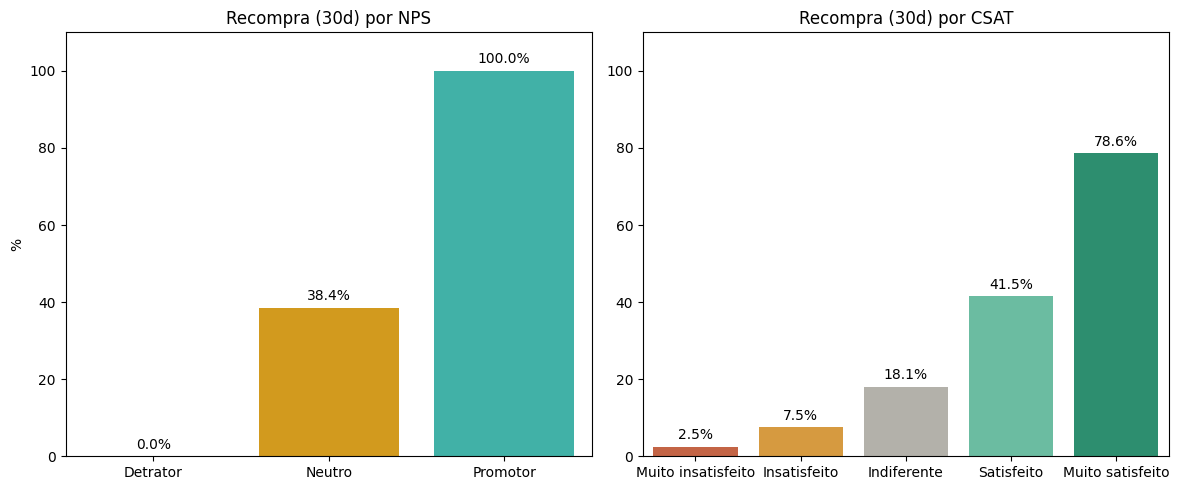

In [55]:
# =========================================================
# Análise da taxa de recompra em 30 dias por NPS e CSAT
#
# Este bloco calcula e compara o percentual de clientes que
# realizaram uma nova compra em até 30 dias, segmentando os
# resultados pelas categorias de NPS e pelos níveis de CSAT.
#
# O objetivo é identificar a relação entre satisfação do
# cliente e comportamento de recompra, verificando se clientes
# mais satisfeitos apresentam maior propensão à fidelização.
#
# Essa análise ajuda a demonstrar o impacto direto da
# experiência do cliente sobre retenção e recorrência de compra.
# =========================================================


# ── Cálculos ────────────────────────
taxa_recompra_nps = df.groupby('nps_category')['repeat_purchase_30d'].mean() * 100
taxa_recompra_csat = df.groupby('csat_category')['repeat_purchase_30d'].mean() * 100

# ── Plot ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# NPS
sns.barplot(
    x=taxa_recompra_nps.index,
    y=taxa_recompra_nps.values,
    palette=[NPS_COLORS.get(cat, '#888') for cat in taxa_recompra_nps.index],
    ax=ax1
)
ax1.set_title('Recompra (30d) por NPS')
ax1.set_ylabel('%')
ax1.set_xlabel('')
ax1.set_ylim(0, 110)

for i, v in enumerate(taxa_recompra_nps.values):
    ax1.text(i, v + 2, f'{v:.1f}%', ha='center')


# CSAT
sns.barplot(
    x=taxa_recompra_csat.index,
    y=taxa_recompra_csat.values,
    palette=[COLORS_CSAT[i] for i in range(len(taxa_recompra_csat))],
    ax=ax2
)
ax2.set_title('Recompra (30d) por CSAT')
ax2.set_ylabel('')
ax2.set_xlabel('')
ax2.set_ylim(0, 110)

for i, v in enumerate(taxa_recompra_csat.values):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center')


plt.tight_layout()
plt.show()

A análise evidencia uma relação direta entre satisfação do cliente e taxa de recompra. Clientes classificados como Promotores apresentam os maiores índices de recompra, chegando a 100%, enquanto os Detratores demonstram baixíssima recorrência, indicando forte risco de perda e evasão.

No CSAT, o comportamento se repete: clientes muito satisfeitos apresentam elevada propensão à recompra, enquanto clientes insatisfeitos possuem baixa retenção. Esse padrão reforça que a experiência do cliente impacta diretamente a fidelização, demonstrando que melhorias na satisfação podem gerar efeito imediato sobre retenção e receita.

---
### Impacto da Entrega no NPS

C:\Users\Edy O Cruel\AppData\Local\Temp\ipykernel_1716\3765499689.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nps_medio_atraso = df.groupby(faixas_atraso)['nps_score'].mean()
C:\Users\Edy O Cruel\AppData\Local\Temp\ipykernel_1716\3765499689.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Edy O Cruel\AppData\Local\Temp\ipykernel_1716\3765499689.py:37: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(


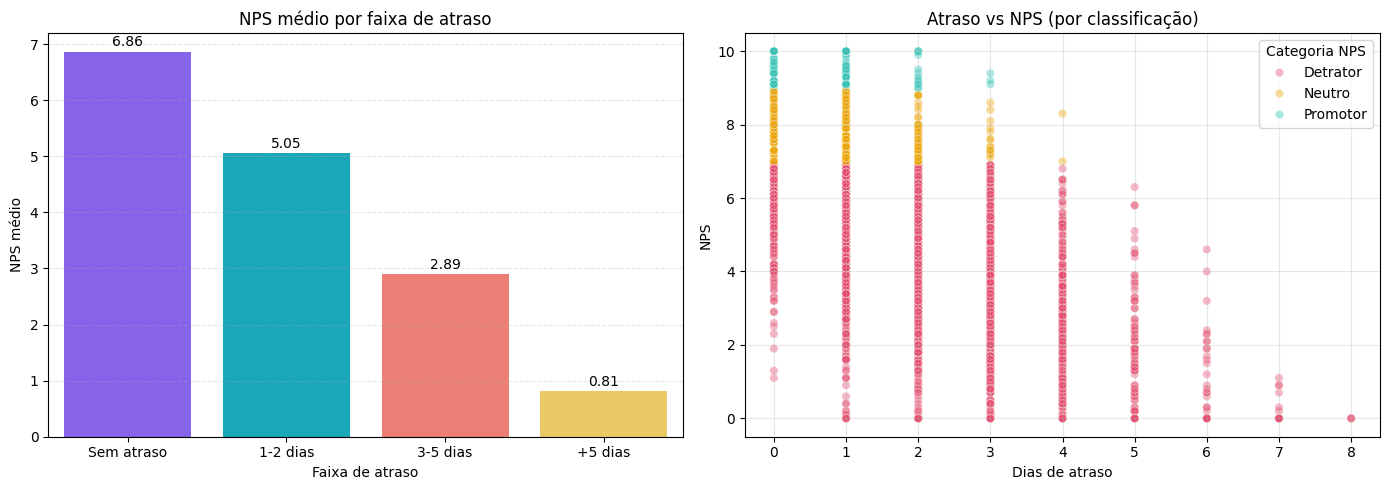

In [56]:
# =========================================================
# Análise do impacto do atraso de entrega no NPS
#
# Este bloco avalia a relação entre os dias de atraso na
# entrega e o nível de satisfação do cliente, medido pelo
# NPS (Net Promoter Score).
#
# A análise é realizada em duas perspectivas:
#
# 1. Agrupamento por faixas de atraso, permitindo observar
#    como o NPS médio se comporta conforme o aumento do
#    tempo de atraso na entrega.
#
# 2. Visualização individual por meio de scatter plot,
#    mostrando a relação entre atraso e classificação do
#    cliente em Detrator, Neutro ou Promotor.
#
# O objetivo é identificar se atrasos logísticos possuem
# impacto direto na percepção de experiência do cliente e
# no aumento da insatisfação.
# =========================================================

faixas_atraso = pd.cut(
    df['delivery_delay_days'],
    bins=[-float('inf'), 0, 2, 5, float('inf')],
    labels=['Sem atraso', '1-2 dias', '3-5 dias', '+5 dias']
)

nps_medio_atraso = df.groupby(faixas_atraso)['nps_score'].mean()

nps_medio_atraso = nps_medio_atraso * 1 

#grafico de colunas 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Barplot (NPS médio por faixa) ───
sns.barplot(
    x=nps_medio_atraso.index,
    y=nps_medio_atraso.values,
    palette=REGION_PAL,
    ax=ax1
)

ax1.set_title('NPS médio por faixa de atraso')
ax1.set_xlabel('Faixa de atraso')
ax1.set_ylabel('NPS médio')

for i, v in enumerate(nps_medio_atraso.values):
    ax1.text(i, v + 0.1, f'{v:.2f}', ha='center')

ax1.grid(axis='y', linestyle='--', alpha=0.3)


# ── Scatter (relação atraso vs NPS) ─
sns.scatterplot(
    x='delivery_delay_days',
    y='nps_score',
    hue='nps_category',
    data=df,
    palette=NPS_COLORS,
    alpha=0.4,
    ax=ax2
)

ax2.set_title('Atraso vs NPS (por classificação)')
ax2.set_xlabel('Dias de atraso')
ax2.set_ylabel('NPS')
ax2.grid(alpha=0.3)

ax2.legend(title='Categoria NPS')

plt.tight_layout()
plt.show()

A análise confirma uma relação direta entre atraso na entrega e queda no NPS. À medida que os dias de atraso aumentam, o nível médio de satisfação do cliente reduz de forma significativa, demonstrando que a tolerância para atrasos é extremamente baixa e que a pontualidade é um fator crítico para a manutenção de um NPS saudável.

Ao mesmo tempo, observa-se a presença de clientes detratores mesmo em situações sem atraso ou com entregas dentro do prazo, indicando que o atraso logístico não é o único fator de insatisfação. Esse comportamento sugere a existência de outros pontos relevantes na jornada do cliente, como atendimento, comunicação, qualidade da entrega e resolução de problemas, que também impactam diretamente a experiência final.

### Atendimento ao Cliente & Reclamações

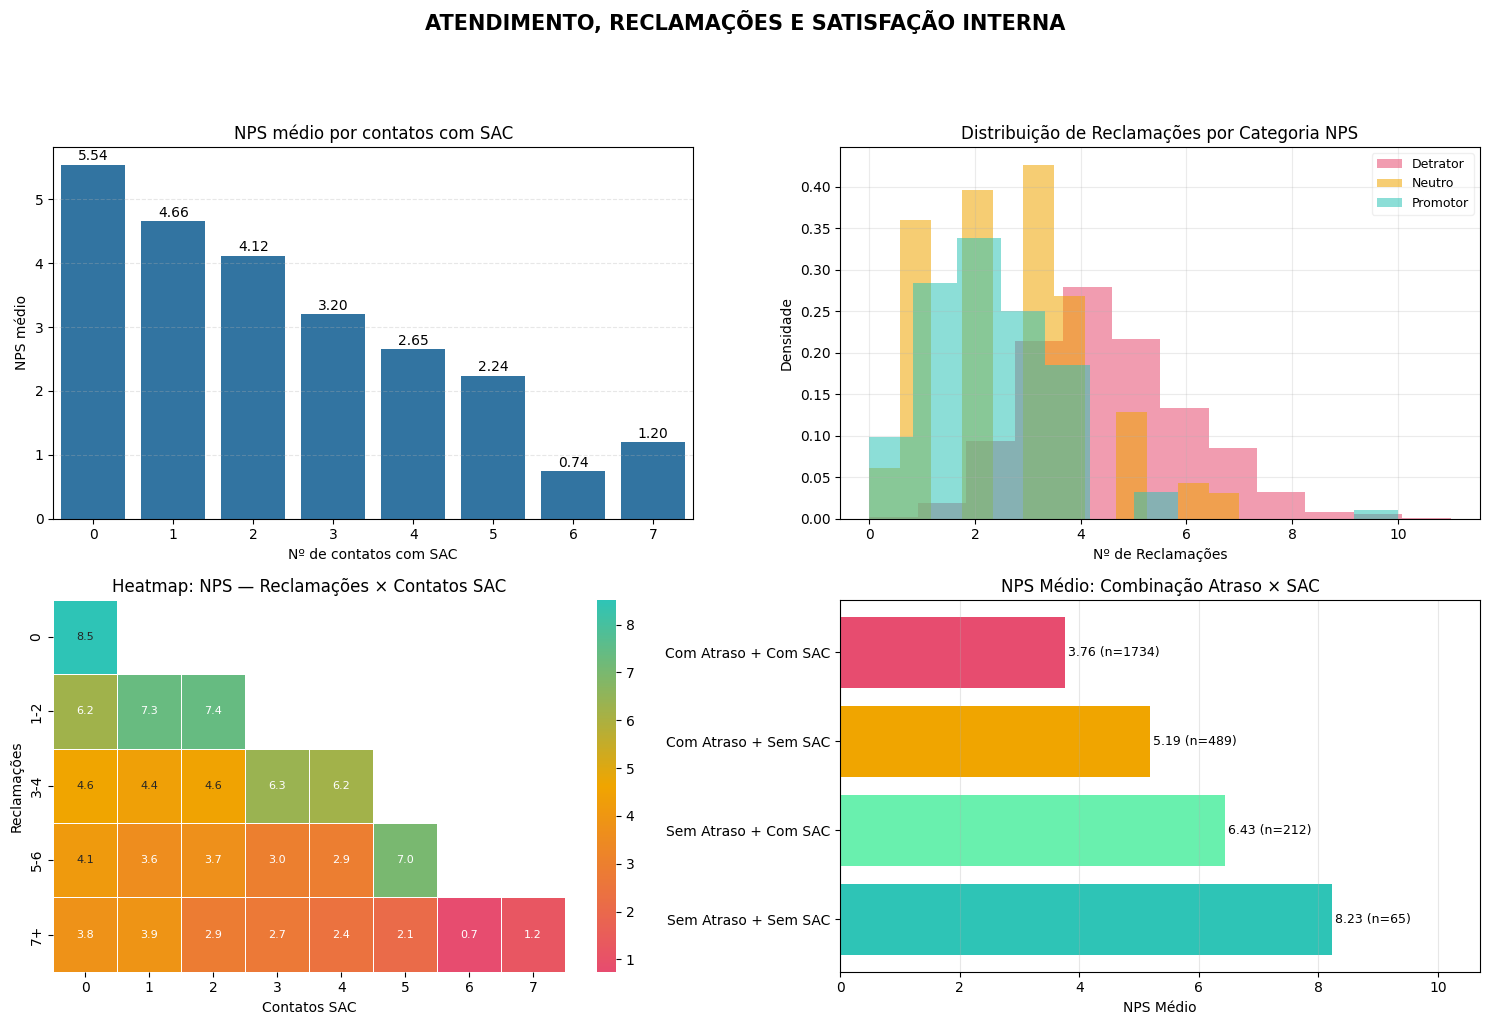

In [57]:
# =========================================================
# Análise integrada de atendimento, reclamações, atraso e NPS
#
# Este bloco avalia como os contatos com o SAC, a quantidade
# de reclamações e o atraso na entrega se relacionam com a
# satisfação do cliente, medida pelo NPS.
#
# A análise é composta por quatro visualizações:
#
# 1. NPS médio por número de contatos com o SAC, permitindo
#    observar se o aumento de interações com atendimento está
#    associado à queda na satisfação.
#
# 2. Distribuição da quantidade de reclamações por categoria
#    de NPS, comparando o comportamento entre Detratores,
#    Neutros e Promotores.
#
# 3. Heatmap combinando reclamações e contatos com o SAC,
#    evidenciando como a intensidade desses eventos afeta o
#    NPS médio.
#
# 4. Comparação do NPS médio considerando a combinação entre
#    atraso na entrega e acionamento do SAC, permitindo medir
#    o impacto acumulado desses fatores na experiência.
#
# O objetivo é identificar sinais operacionais que aumentam
# o risco de insatisfação e apoiar ações preventivas para
# melhorar a jornada do cliente.
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# -------------------------
# 1) NPS médio por contatos
# -------------------------
ax1 = axes[0, 0]

sns.barplot(
    data=df,
    x='customer_service_contacts',
    y='nps_score',
    estimator='mean',
    errorbar=None,
    ax=ax1
)

ax1.set(
    title='NPS médio por contatos com SAC',
    xlabel='Nº de contatos com SAC',
    ylabel='NPS médio'
)

ax1.bar_label(ax1.containers[0], fmt='%.2f', padding=1)
ax1.grid(axis='y', linestyle='--', alpha=0.3)


# -------------------------
# 2) Histograma reclamações
# -------------------------
ax2 = axes[0, 1]

for cat, color in NPS_COLORS.items():
    ax2.hist(
        df.loc[df['nps_category'] == cat, 'complaints_count'],
        bins=12,
        alpha=0.55,
        label=cat,
        color=color,
        density=True,
        edgecolor='none'
    )

ax2.set(
    title='Distribuição de Reclamações por Categoria NPS',
    xlabel='Nº de Reclamações',
    ylabel='Densidade'
)

ax2.legend(fontsize=9, framealpha=0.3)
ax2.grid(alpha=0.25)


# -------------------------
# 3) Heatmap
# -------------------------
ax3 = axes[1, 0]

df['comp_bin'] = pd.cut(
    df['complaints_count'],
    bins=[-1, 0, 2, 4, 6, float('inf')],
    labels=['0', '1-2', '3-4', '5-6', '7+']
)

pivot2 = df.pivot_table(
    values='nps_score',
    index='comp_bin',
    columns='customer_service_contacts',
    aggfunc='mean',
    observed=True
)

sns.heatmap(
    pivot2,
    ax=ax3,
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cmap=HEAT_CMAP,
    annot_kws={'size': 8}
)

ax3.set(
    title='Heatmap: NPS — Reclamações × Contatos SAC',
    xlabel='Contatos SAC',
    ylabel='Reclamações'
)


# -------------------------
# 4) Impacto combinado atraso + SAC
# -------------------------

delay = df['delivery_delay_days'] > 0
sac = df['customer_service_contacts'] > 0

df['combo'] = (
    delay.map({False: 'Sem Atraso', True: 'Com Atraso'}) +
    ' + ' +
    sac.map({False: 'Sem SAC', True: 'Com SAC'})
)

combo_nps = (
    df.groupby('combo')
      .agg(mean=('nps_score', 'mean'), count=('nps_score', 'size'))
      .sort_values('mean', ascending=False)
)

ax4 = axes[1, 1]

bars = ax4.barh(
    combo_nps.index,
    combo_nps['mean'],
    color=['#2ec4b6','#69f0ae','#f0a500','#e74c6f']
)

for bar, row in zip(bars, combo_nps.itertuples()):
    ax4.text(
        row.mean + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{row.mean:.2f} (n={row.count})",
        va='center',
        fontsize=9
    )

ax4.set_title('NPS Médio: Combinação Atraso × SAC')
ax4.set_xlabel('NPS Médio')
ax4.set_xlim(0, combo_nps['mean'].max() * 1.3)
ax4.grid(axis='x', alpha=0.3)

fig.suptitle(
    'ATENDIMENTO, RECLAMAÇÕES E SATISFAÇÃO INTERNA',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

A análise evidencia que, quanto maior a necessidade de o cliente acionar o suporte para tratar problemas como atrasos e reclamações, maior é a probabilidade de ele se tornar um cliente detrator. O aumento no número de contatos com o SAC e no volume de reclamações está diretamente associado à redução do NPS médio, reforçando o impacto negativo dessas ocorrências na percepção de valor.

Além disso, os resultados demonstram que o suporte atua majoritariamente de forma reativa, após a falha já ter comprometido a experiência do cliente. Em muitos casos, o atendimento não consegue recuperar a percepção negativa gerada por uma operação logística ineficiente, evidenciando que a principal alavanca de melhoria está na prevenção das falhas operacionais, e não apenas na tratativa posterior.

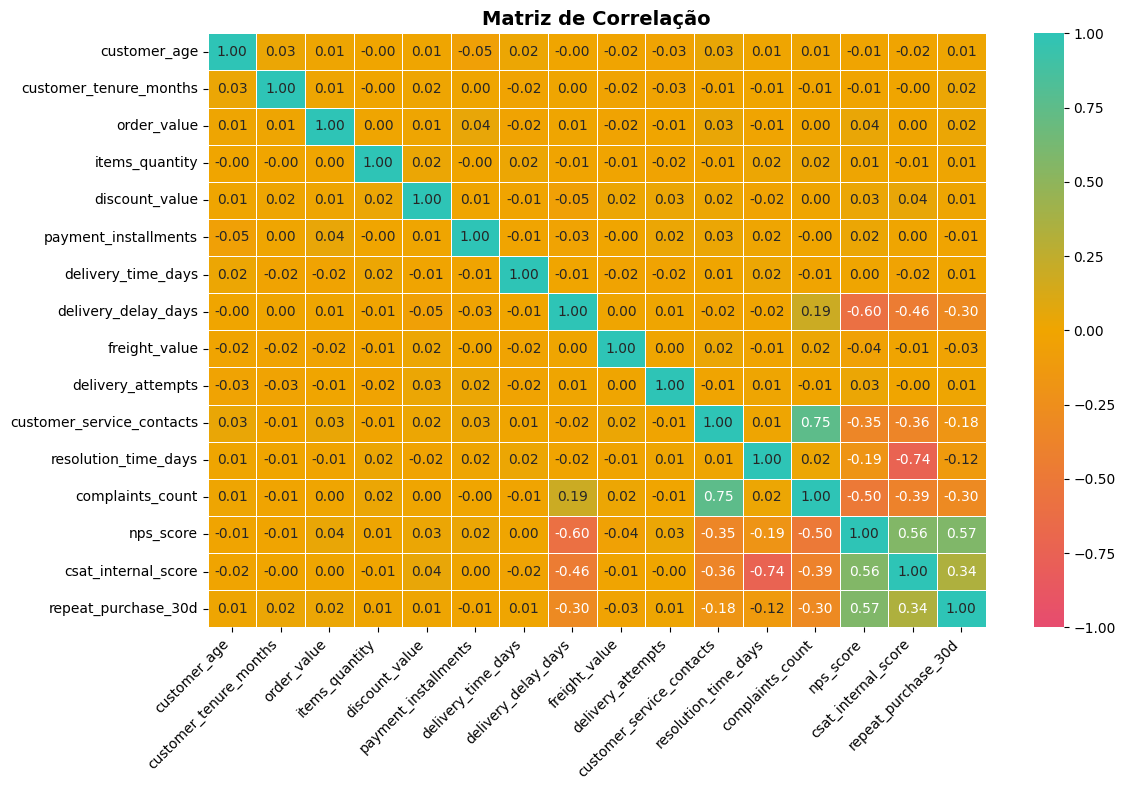

In [58]:

# =========================================================
# Matriz de correlação entre variáveis operacionais e NPS
#
# Este bloco calcula e exibe a correlação entre as principais
# variáveis numéricas da base, com foco especial nos fatores
# que podem impactar diretamente o NPS e a satisfação do cliente.
#
# A análise considera indicadores relacionados a:
# - perfil do cliente
# - tempo de relacionamento
# - características do pedido
# - atraso e tempo de entrega
# - frete e tentativas de entrega
# - contatos com atendimento
# - tempo de resolução
# - quantidade de reclamações
# - recompra e satisfação interna
#
# O objetivo é identificar relações positivas e negativas
# entre variáveis, permitindo reconhecer os principais
# direcionadores da satisfação e apoiar as próximas etapas
# de modelagem preditiva no CRISP-DM.
# =========================================================

cols_corr = [
    'customer_age', 'customer_tenure_months', 'order_value', 'items_quantity',
    'discount_value', 'payment_installments', 'delivery_time_days',
    'delivery_delay_days', 'freight_value', 'delivery_attempts',
    'customer_service_contacts', 'resolution_time_days',
    'complaints_count', 'nps_score', 'csat_internal_score','repeat_purchase_30d'
]

cols_corr = [c for c in cols_corr if c in df.columns]
corr = df[cols_corr].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap=HEAT_CMAP,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title('Matriz de Correlação', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

A matriz de correlação demonstra que a satisfação do cliente está muito mais relacionada à eficiência operacional do que ao perfil individual do consumidor. Variáveis como idade, valor do pedido e quantidade de itens apresentam baixa influência sobre o NPS, indicando que fatores demográficos ou financeiros não são os principais determinantes da percepção de experiência.

Por outro lado, variáveis operacionais como atraso na entrega (-0,60) e tempo de resolução de problemas (-0,74) apresentam forte correlação negativa com o NPS e o CSAT, evidenciando seu impacto direto na insatisfação. O gráfico também revela um ciclo operacional crítico: atrasos geram maior necessidade de contato com o suporte, esses contatos evoluem para reclamações (correlação de 0,75), e a soma desses fatores compromete significativamente a satisfação do cliente. Isso reforça que a melhoria da experiência depende prioritariamente da eficiência operacional e da redução de falhas na jornada.


C:\Users\Edy O Cruel\AppData\Local\Temp\ipykernel_1716\4161116354.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


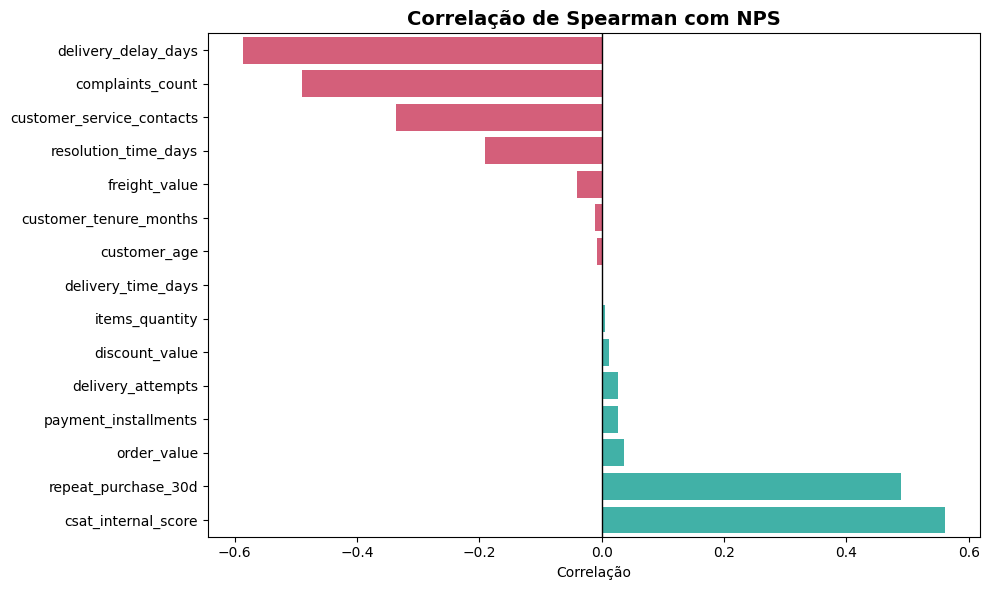

In [59]:
# =========================================================
# Correlação de Spearman entre variáveis e NPS
#
# Este bloco calcula a correlação de Spearman entre o
# NPS e as principais variáveis numéricas da base,
# permitindo identificar quais fatores possuem maior
# influência positiva ou negativa sobre a satisfação
# do cliente.
#
# Diferente da correlação linear tradicional (Pearson),
# o método de Spearman avalia relações monotônicas,
# sendo mais robusto para dados com assimetria,
# outliers e comportamentos não lineares.
#
# O gráfico em barras facilita a visualização dos
# principais direcionadores do NPS, destacando quais
# variáveis aumentam ou reduzem a satisfação do cliente.
#
# O objetivo é apoiar a priorização das causas mais
# relevantes de insatisfação e fortalecer a etapa de
# entendimento dos dados dentro do CRISP-DM.
# =========================================================

corr_nps = (
    df[cols_corr]
    .corr(method='spearman')['nps_score']
    .drop('nps_score')
    .sort_values()
)
neg_color = HEAT_CMAP(0.0)  
pos_color = HEAT_CMAP(1.0)  

colors = [pos_color if v > 0 else neg_color for v in corr_nps.values]

plt.figure(figsize=(10, 6))

sns.barplot(
    y=corr_nps.index,
    x=corr_nps.values,
    palette=colors
)

plt.axvline(0, color='black', linewidth=1)

plt.title('Correlação de Spearman com NPS', fontsize=14, fontweight='bold')
plt.xlabel('Correlação')
plt.ylabel('')

plt.tight_layout()
plt.show()


O gráfico de correlação de Spearman evidencia com clareza os principais fatores que impulsionam e os que comprometem o NPS, funcionando como um verdadeiro “quem é quem” da satisfação do cliente.

Entre os principais fatores que destroem o NPS, destacam-se o atraso na entrega, a quantidade de reclamações, o volume de contatos com o SAC e o tempo de resolução, todos com forte correlação negativa. Esses indicadores mostram que falhas operacionais e dificuldades na resolução de problemas impactam diretamente a percepção do cliente e aumentam significativamente a probabilidade de insatisfação.

Por outro lado, variáveis como CSAT interno e recompra em 30 dias apresentam forte correlação positiva, demonstrando que clientes mais satisfeitos tendem naturalmente a permanecer, recomprar e manter uma relação mais saudável com a empresa. O gráfico reforça que o NPS não está ligado ao perfil do cliente, mas sim à eficiência da operação e à qualidade da experiência entregue.